# Predicting Resource Bottlenecks and Cloud Cost Spikes in Distributed Job Processing Architectures

**Business Analytics (23CSE452) - Individual Case Study**
**Name:** Adhikkesh S K  **Register Number:** CB.SC.U4CSE23101  **Class:** CSE-B

This notebook contains the complete analytics workflow of the case study: data understanding, data preprocessing,
exploratory data analysis (EDA), predictive modelling, model evaluation and the business insights derived from the
results. The code used to collect the dataset (web scraping + job record generation) is given in Appendix A at the end of
the notebook and in the `scripts/` folder.

## 1. Problem Statement and Objectives

Organisations that run large data pipelines (web scraping, document processing, ETL, model training) on distributed
worker clusters frequently face sudden resource bottlenecks: a heavy job lands on a node with too little free memory
or an already busy CPU, the node chokes, the job slows down or is retried, and the cloud bill rises. Because the risk
of a job is not known before it runs, teams either over-provision the whole cluster "just in case" or react to
incidents after they happen.

**Objectives**
1. **Diagnose the root cause** – identify which job attributes and node conditions drive CPU/memory bottlenecks.
2. **Build an early-warning model** – classify an incoming job as *Bottleneck* (high risk) or *Normal* using only
   information available **before** the job is executed.
3. **Enable cost-aware scaling** – quantify the cost impact of bottlenecks and recommend scheduling/scaling actions
   that tie cloud spend to actual risk.

## 2. Data Collection (summary)

The dataset was built in two stages (full code in Appendix A):

| Stage | Method | Output |
|---|---|---|
| 1. Web scraping | The public AWS EC2 instance comparison page **https://instances.vantage.sh/** was scraped with the Apify Web Scraper (custom page function) and with a Python scraper (headless Chrome + BeautifulSoup), because the table is generated by JavaScript. Both gave the same values for the 1,242 records Apify returned, and the complete Python scrape was used. | 1,413 real instance types × 14 attributes (name, API name, compute family, memory, vCPUs, storage, network performance, on-demand / reserved / spot prices). |
| 2. Synthetic workload generation | Production job logs are confidential, so 10,000 job-execution records were simulated. **Every job is dispatched to a worker node whose hardware and hourly price are a real scraped instance type.** Job telemetry is generated from realistic distributions and the label is derived from a resource-pressure score that uses the node's scraped capacity. | 10,035 raw job records × 27 attributes (includes realistic data-quality problems). |

Columns taken directly from the scraped page keep their original text format (e.g. `"16 GiB"`, `"8 vCPUs"`,
`"$0.2040 hourly"`), so they must be parsed during preprocessing.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, classification_report, precision_recall_curve)

warnings.filterwarnings("ignore")
SEED = 23101
DATA_PATH = "data/cloud_job_execution_dataset.csv"
CLEAN_PATH = "data/cleaned_job_dataset.csv"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# colours used in all charts (blue = Normal, orange = Bottleneck)
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#898781"
INK, INK2, GRID, AXIS = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
BLUE_LIGHT = "#86b6ef"
CLASS_COLORS = {"Normal": BLUE, "Bottleneck": ORANGE}
MODEL_COLORS = {"Logistic Regression": BLUE, "Decision Tree": ORANGE, "Random Forest": AQUA}
BLUE_RAMP = LinearSegmentedColormap.from_list("blues", ["#f2f7fd", "#b7d3f6", "#6da7ec", "#2a78d6", "#1c5cab"])
DIVERGING = LinearSegmentedColormap.from_list("diverging", ["#2a78d6", "#f0efec", "#e34948"])
HALF, FULL = (3.5, 2.7), 7.0
PCT = mpl.ticker.PercentFormatter(1.0, decimals=0)
mpl.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 260, "savefig.bbox": "tight", "savefig.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 8, "axes.titlesize": 8.6, "axes.titleweight": "bold", "axes.titlepad": 6,
    "axes.labelsize": 7.8, "xtick.labelsize": 7.2, "ytick.labelsize": 7.2, "legend.fontsize": 7.2,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "axes.titlecolor": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.prop_cycle": mpl.cycler(color=[BLUE, ORANGE, AQUA]), "legend.frameon": False, "lines.linewidth": 1.8,
})

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")

def style_box(bp, colors):
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_edgecolor(c); patch.set_alpha(0.9)
    for part in ("whiskers", "caps"):
        for line in bp[part]:
            line.set_color(INK2); line.set_linewidth(0.9)
    for med in bp["medians"]:
        med.set_color("white"); med.set_linewidth(1.6)

## 3. Data Understanding

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"Raw dataset: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Raw dataset: 10,035 rows x 27 columns


,job_id,submitted_at,job_category,priority_level,region,payload_size_mb,executor_memory_mb,replica_count,retry_count,node_instance_type,...,pod_memory_available_pct,active_thread_count,broker_latency_ms,queue_wait_time_ms,disk_io_mbps,network_io_mbps,gc_pause_time_ms,execution_time_sec,job_cost_usd,target_label
0,JOB-102129,2026-07-21 08:32,MLTraining,Low,us-east,84.63,2048,2,0,m8gn.8xlarge,...,58.1,15,46.4,33.3,15.78,28.46,4.0,99.8,0.12907,Normal
1,JOB-103600,2026-06-03 15:50,DocumentProcessing,Low,eu-central,13.84,4096,4,0,m4.large,...,33.9,9,69.7,146.8,52.43,32.93,1.0,199.2,0.02213,Bottleneck
2,JOB-101552,2026-08-11 14:16,ETL,Low,us-east,21.72,512,3,0,r7gd.4xlarge,...,61.9,15,27.4,60.9,44.70,NaN,20.2,36.7,0.03329,Normal
3,JOB-104615,2026-08-03 13:06,DocumentProcessing,Medium,ap-south,52.36,1024,3,0,r8gn.8xlarge,...,34.6,16,52.5,172.4,38.05,46.71,0.2,47.9,0.11635,Normal
4,JOB-104497,2026-06-03 06:51,ETL,High,ap-south,11.60,4096,2,0,r6id.2xlarge,...,54.5,10,55.6,170.2,43.85,43.12,21.0,34.2,0.01149,Normal


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10035 entries, 0 to 10034
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   job_id                    10035 non-null  str    
 1   submitted_at              10035 non-null  str    
 2   job_category              10035 non-null  str    
 3   priority_level            10035 non-null  str    
 4   region                    10035 non-null  str    
 5   payload_size_mb           10035 non-null  float64
 6   executor_memory_mb        10035 non-null  int64  
 7   replica_count             10035 non-null  int64  
 8   retry_count               10035 non-null  int64  
 9   node_instance_type        10035 non-null  str    
 10  node_family               10035 non-null  str    
 11  node_vcpus                10035 non-null  str    
 12  node_memory               10035 non-null  str    
 13  node_network              10035 non-null  str    
 14  node_price_hourly

In [4]:
raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
payload_size_mb,10035.0,57.55,69.72,0.75,17.52,35.03,70.55,902.16
executor_memory_mb,10035.0,2251.82,1956.20,512.00,1024.00,2048.00,2048.00,8192.00
replica_count,10035.0,2.60,1.16,1.00,2.00,2.00,3.00,5.00
retry_count,10035.0,0.35,0.70,0.00,0.00,0.00,0.00,3.00
cpu_utilization_pct,10035.0,55.12,19.46,2.00,42.10,55.20,68.00,177.30
pod_memory_available_pct,9954.0,56.35,19.22,3.00,43.50,56.50,69.70,97.00
active_thread_count,10035.0,12.52,3.87,1.00,10.00,12.00,15.00,33.00
broker_latency_ms,9883.0,47.81,27.96,-1.00,27.90,42.50,62.40,289.90
queue_wait_time_ms,9835.0,99.60,78.37,0.50,42.80,78.90,134.40,638.40
disk_io_mbps,10035.0,40.16,15.77,1.00,29.35,40.26,50.67,99.57


**Attribute dictionary**

| Group | Attributes | Source |
|---|---|---|
| Identifier / time | `job_id`, `submitted_at` | simulated |
| Job profile | `job_category`, `priority_level`, `region`, `payload_size_mb`, `executor_memory_mb`, `replica_count`, `retry_count` | simulated |
| Worker node (hardware & price) | `node_instance_type`, `node_family`, `node_vcpus`, `node_memory`, `node_network`, `node_price_hourly`, `node_spot_price_hourly` | **scraped** (instances.vantage.sh) |
| Node state at assignment | `cpu_utilization_pct`, `pod_memory_available_pct`, `active_thread_count`, `broker_latency_ms`, `queue_wait_time_ms`, `disk_io_mbps`, `network_io_mbps`, `gc_pause_time_ms` | simulated |
| Outcome (known only after execution) | `execution_time_sec`, `job_cost_usd` | simulated from scraped price |
| Target | `target_label` (*Bottleneck* / *Normal*) | derived |

In [5]:
print("Distinct real instance types used as worker nodes:", raw["node_instance_type"].nunique())
print(raw["node_family"].value_counts())
raw["target_label"].value_counts().to_frame("jobs").assign(share=lambda t: (t["jobs"] / t["jobs"].sum()).round(3))

Distinct real instance types used as worker nodes: 979
node_family
Memory optimized     3216
General purpose      3118
Compute optimized    2726
Storage optimized     975
Name: count, dtype: int64


,jobs,share
target_label,,
Normal,6720,0.67
Bottleneck,3315,0.33


## 4. Data Preprocessing

The raw data contains the problems typically found in scraped values and telemetry logs: duplicate log writes,
inconsistent category spellings, text-formatted numeric fields, sensor glitches (impossible readings and a `-1`
"no reading" sentinel) and missing telemetry values. Each is handled below.

### 4.1 Duplicate records

In [6]:
df = raw.copy()
n_dup = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print(f"Exact duplicate rows removed: {n_dup}  ->  {len(df):,} rows remain")
print("Remaining duplicated job_id values:", int(df["job_id"].duplicated().sum()))

Exact duplicate rows removed: 35  ->  10,000 rows remain
Remaining duplicated job_id values: 0


### 4.2 Standardising inconsistent category labels

In [7]:
print("job_category values before cleaning:", sorted(df["job_category"].unique()))
print("region values before cleaning:", sorted(df["region"].unique()))

canonical = {"webscraping": "WebScraping", "documentprocessing": "DocumentProcessing", "docprocessing": "DocumentProcessing",
             "etl": "ETL", "mltraining": "MLTraining", "aggregation": "Aggregation", "streaming": "Streaming"}
key = df["job_category"].str.strip().str.lower().str.replace(r"[\s_]", "", regex=True)
n_fixed_cat = int((df["job_category"] != key.map(canonical)).sum())
df["job_category"] = key.map(canonical)
n_fixed_region = int((df["region"] != df["region"].str.strip().str.lower()).sum())
df["region"] = df["region"].str.strip().str.lower()
assert df["job_category"].notna().all()

print(f"\nRelabelled {n_fixed_cat} job_category values and {n_fixed_region} region values")
print("job_category values after cleaning:", sorted(df["job_category"].unique()))

job_category values before cleaning: ['Aggregation', 'Doc Processing', 'DocumentProcessing', 'ETL', 'ETL ', 'ML Training', 'MLTraining', 'Streaming', 'Streaming ', 'Web Scraping', 'WebScraping', 'aggregation', 'documentprocessing', 'etl', 'mltraining', 'streaming', 'web_scraping ', 'webscraping']
region values before cleaning: ['AP-SOUTH', 'EU-CENTRAL', 'US-EAST', 'US-WEST', 'ap-south', 'eu-central', 'us-east', 'us-west']

Relabelled 300 job_category values and 200 region values


job_category values after cleaning: ['Aggregation', 'DocumentProcessing', 'ETL', 'MLTraining', 'Streaming', 'WebScraping']


### 4.3 Parsing the scraped text fields into numbers

Legacy AWS instance generations report network performance as the words *Moderate* / *High* instead of a
bandwidth. These were converted to approximate values (Moderate ≈ 1 Gbps, High ≈ 10 Gbps). Burstable
("Up to …") bandwidth is kept as a separate flag.

In [8]:
def to_number(s):
    return pd.to_numeric(s.astype(str).str.replace(",", "", regex=False).str.extract(r"(\d+\.?\d*)")[0], errors="coerce")

df["node_vcpus_n"] = to_number(df["node_vcpus"]).astype(int)
df["node_memory_gib"] = to_number(df["node_memory"])
df["node_price_usd_hr"] = to_number(df["node_price_hourly"])
df["node_spot_price_usd_hr"] = to_number(df["node_spot_price_hourly"])          # "-" (no spot market) -> NaN
df["node_network_gbps"] = to_number(df["node_network"]).fillna(df["node_network"].map({"Moderate": 1.0, "High": 10.0}))
df["node_network_burst"] = df["node_network"].str.startswith("Up to").astype(int)

df[["node_vcpus", "node_vcpus_n", "node_memory", "node_memory_gib", "node_price_hourly", "node_price_usd_hr",
    "node_network", "node_network_gbps"]].drop_duplicates().head(6)

,node_vcpus,node_vcpus_n,node_memory,node_memory_gib,node_price_hourly,node_price_usd_hr,node_network,node_network_gbps
0,32 vCPUs,32,128 GiB,128.0,$2.3280 hourly,2.3280,100 Gigabit,100.0
1,2 vCPUs,2,8 GiB,8.0,$0.1000 hourly,0.1000,Moderate,1.0
2,16 vCPUs,16,128 GiB,128.0,$1.0886 hourly,1.0886,Up to 15 Gigabit,15.0
3,32 vCPUs,32,256 GiB,256.0,$2.9149 hourly,2.9149,100 Gigabit,100.0
4,8 vCPUs,8,64 GiB,64.0,$0.6048 hourly,0.6048,Up to 12.5 Gigabit,12.5
5,2 vCPUs,2,8 GiB,8.0,$0.0860 hourly,0.0860,Up to 10 Gigabit,10.0


### 4.4 Invalid sensor readings and missing values

In [9]:
bad_cpu = df["cpu_utilization_pct"] > 100
bad_lat = df["broker_latency_ms"] < 0
print(f"CPU utilisation readings above 100% (impossible): {bad_cpu.sum()}")
print(f"Broker latency '-1' sentinel values:              {bad_lat.sum()}")
df.loc[bad_cpu, "cpu_utilization_pct"] = np.nan
df.loc[bad_lat, "broker_latency_ms"] = np.nan

telemetry_cols = ["cpu_utilization_pct", "pod_memory_available_pct", "broker_latency_ms",
                  "queue_wait_time_ms", "network_io_mbps", "gc_pause_time_ms"]
missing = df[telemetry_cols + ["node_spot_price_usd_hr"]].isna().sum().sort_values()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "percent": missing_pct})

CPU utilisation readings above 100% (impossible): 22
Broker latency '-1' sentinel values:              18


,missing,percent
cpu_utilization_pct,22,0.22
node_spot_price_usd_hr,38,0.38
pod_memory_available_pct,80,0.80
gc_pause_time_ms,100,1.00
broker_latency_ms,168,1.68
queue_wait_time_ms,200,2.00
network_io_mbps,250,2.50


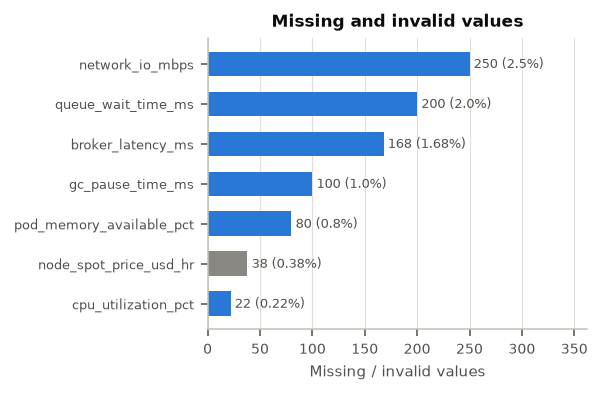

In [10]:
fig, ax = plt.subplots(figsize=HALF)
bars = ax.barh(missing.index, missing.values, height=0.62,
               color=[GREY if c == "node_spot_price_usd_hr" else BLUE for c in missing.index])
for b, v, p in zip(bars, missing.values, missing_pct.values):
    ax.text(b.get_width() + 4, b.get_y() + b.get_height() / 2, f"{v} ({p}%)", va="center", fontsize=6.6, color=INK2)
ax.set_xlabel("Missing / invalid values"); ax.set_xlim(0, missing.max() * 1.45)
ax.set_title("Missing and invalid values"); ax.grid(axis="y", visible=False); ax.tick_params(axis="y", labelsize=6.6)
save(fig, "fig_missing_values"); plt.show()

In [11]:
# telemetry gaps are filled with the median of the same job category (robust to the skewed distributions)
for c in telemetry_cols:
    df[c] = df[c].fillna(df.groupby("job_category")[c].transform("median"))
print("Remaining missing values in telemetry columns:", int(df[telemetry_cols].isna().sum().sum()))
print("node_spot_price_usd_hr stays missing for", int(df["node_spot_price_usd_hr"].isna().sum()),
      "jobs (those instance types have no spot market); it is used only in the cost analysis.")

Remaining missing values in telemetry columns: 0
node_spot_price_usd_hr stays missing for 38 jobs (those instance types have no spot market); it is used only in the cost analysis.


### 4.5 Outlier analysis

In [12]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return int(((s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))).sum())

outlier_table = pd.DataFrame({c: [iqr_outliers(df[c]), df[c].max()] for c in
                              ["payload_size_mb", "queue_wait_time_ms", "gc_pause_time_ms", "broker_latency_ms", "execution_time_sec"]},
                             index=["IQR outliers", "max value"]).T
outlier_table

,IQR outliers,max value
payload_size_mb,737.0,902.16
queue_wait_time_ms,409.0,638.40
gc_pause_time_ms,458.0,330.50
broker_latency_ms,293.0,289.90
execution_time_sec,1229.0,18072.70


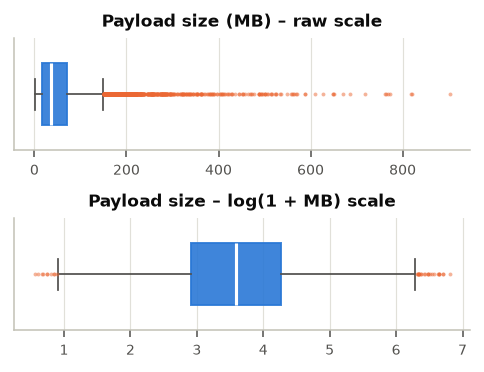

In [13]:
fig, axes = plt.subplots(2, 1, figsize=HALF)
for ax, data, title in [(axes[0], df["payload_size_mb"], "Payload size (MB) – raw scale"),
                        (axes[1], np.log1p(df["payload_size_mb"]), "Payload size – log(1 + MB) scale")]:
    bp = ax.boxplot(data, vert=False, widths=0.55, patch_artist=True,
                    flierprops=dict(marker="o", markersize=2, markerfacecolor=ORANGE, markeredgecolor="none", alpha=0.5))
    style_box(bp, [BLUE]); ax.set_yticks([]); ax.set_title(title)
fig.tight_layout(h_pad=1.0); save(fig, "fig_outliers_payload"); plt.show()

The large payloads are genuine heavy jobs (the right tail expected in web-scraping and ML workloads), not errors, so
they are **retained**. Right-skewed variables (payload size, memory-pressure ratio) are log-transformed before modelling.

### 4.6 Feature engineering

In [14]:
ts = pd.to_datetime(df["submitted_at"])
df["submit_hour"] = ts.dt.hour
df["day_of_week"] = ts.dt.dayofweek
df["is_peak_hour"] = df["submit_hour"].between(9, 17).astype(int)
df["available_memory_mb"] = df["node_memory_gib"] * 1024 * df["pod_memory_available_pct"] / 100
df["memory_pressure_ratio"] = df["payload_size_mb"] / df["available_memory_mb"]
df["memory_pressure_log"] = np.log(df["memory_pressure_ratio"])
df["payload_size_mb_log"] = np.log1p(df["payload_size_mb"])
df["threads_per_vcpu"] = df["active_thread_count"] / df["node_vcpus_n"]
df["memory_per_vcpu_gib"] = df["node_memory_gib"] / df["node_vcpus_n"]
df["is_bottleneck"] = (df["target_label"] == "Bottleneck").astype(int)

print(f"Clean analytical dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df[["payload_size_mb", "node_memory_gib", "pod_memory_available_pct", "memory_pressure_ratio",
    "active_thread_count", "node_vcpus_n", "threads_per_vcpu"]].describe().T.round(3)

Clean analytical dataset: 10,000 rows x 43 columns


,count,mean,std,min,25%,50%,75%,max
payload_size_mb,10000.0,57.599,69.780,0.750,17.518,35.065,70.638,902.160
node_memory_gib,10000.0,86.414,139.701,1.700,15.250,32.000,96.000,768.000
pod_memory_available_pct,10000.0,56.347,19.131,3.000,43.600,56.500,69.525,97.000
memory_pressure_ratio,10000.0,0.008,0.026,0.000,0.001,0.002,0.007,1.517
active_thread_count,10000.0,12.524,3.874,1.000,10.000,12.000,15.000,33.000
node_vcpus_n,10000.0,16.602,23.510,2.000,2.000,4.000,16.000,96.000
threads_per_vcpu,10000.0,2.702,2.365,0.052,0.688,2.000,4.250,13.500


### 4.7 Saving the cleaned dataset

The cleaned and feature-engineered table is written to `data/cleaned_job_dataset.csv` so it can be reused without re-running the preprocessing steps.

In [15]:
df.to_csv(CLEAN_PATH, index=False)
print(f"Cleaned dataset saved: {df.shape[0]:,} rows x {df.shape[1]} columns -> {CLEAN_PATH}")

Cleaned dataset saved: 10,000 rows x 43 columns -> data/cleaned_job_dataset.csv


## 5. Exploratory Data Analysis

### 5.1 Scraped worker-node catalogue

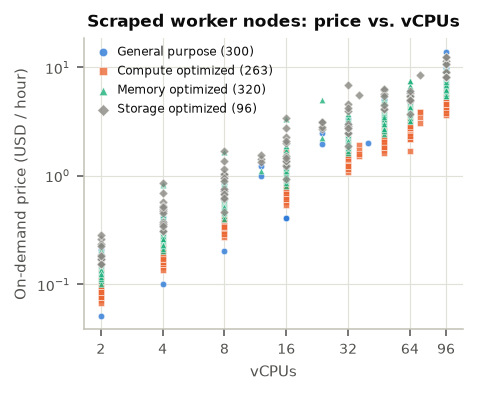

979 distinct scraped instance types; price range $0.0510 – $13.97 per hour


In [16]:
nodes = df.drop_duplicates("node_instance_type")
fam_style = {"General purpose": (BLUE, "o"), "Compute optimized": (ORANGE, "s"),
             "Memory optimized": (AQUA, "^"), "Storage optimized": (GREY, "D")}
fig, ax = plt.subplots(figsize=HALF)
for fam, (col, mk) in fam_style.items():
    g = nodes[nodes["node_family"] == fam]
    ax.scatter(g["node_vcpus_n"], g["node_price_usd_hr"], s=11, marker=mk, c=col, alpha=0.8,
               edgecolors="white", linewidths=0.3, label=f"{fam} ({len(g)})")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xticks([2, 4, 8, 16, 32, 64, 96], ["2", "4", "8", "16", "32", "64", "96"]); ax.minorticks_off()
ax.set_xlabel("vCPUs"); ax.set_ylabel("On-demand price (USD / hour)")
ax.set_title("Scraped worker nodes: price vs. vCPUs")
ax.legend(loc="upper left", fontsize=6.2, markerscale=1.3, handletextpad=0.2, borderaxespad=0.2)
save(fig, "fig_node_catalogue"); plt.show()
print(f"{len(nodes)} distinct scraped instance types; price range ${nodes['node_price_usd_hr'].min():.4f} – ${nodes['node_price_usd_hr'].max():.2f} per hour")

### 5.2 Target variable

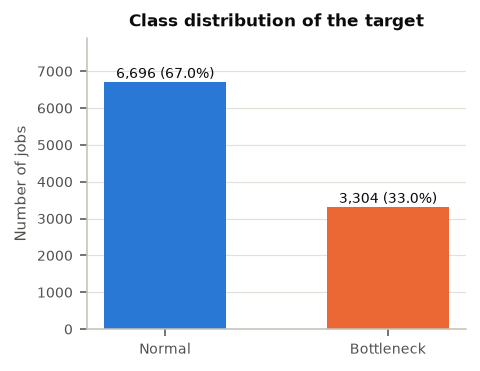

In [17]:
counts = df["target_label"].value_counts()
fig, ax = plt.subplots(figsize=HALF)
bars = ax.bar(counts.index, counts.values, color=[CLASS_COLORS[k] for k in counts.index], width=0.55)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 120, f"{v:,} ({v / counts.sum():.1%})", ha="center", fontsize=7.4, color=INK)
ax.set_ylabel("Number of jobs"); ax.set_ylim(0, counts.max() * 1.18)
ax.set_title("Class distribution of the target"); ax.grid(axis="x", visible=False)
save(fig, "fig_target_distribution"); plt.show()

### 5.3 Bottleneck rate by job category, priority and time of day

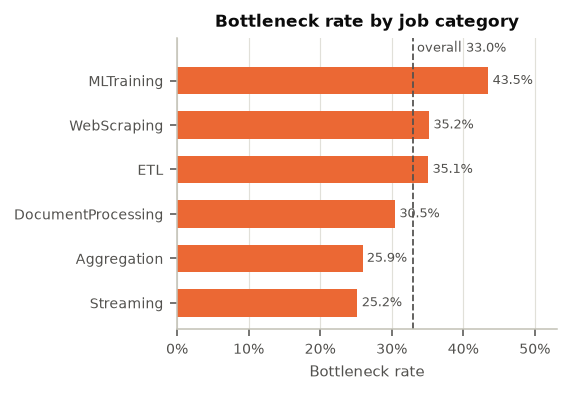

,mean,size
job_category,,
Streaming,0.252,900
Aggregation,0.259,1454
DocumentProcessing,0.305,1965
ETL,0.351,1834
WebScraping,0.352,2622
MLTraining,0.435,1225


,mean,size
priority_level,,
Low,0.353,2988
Medium,0.332,3748
High,0.319,2195
Critical,0.283,1069


In [18]:
overall = df["is_bottleneck"].mean()
rate_cat = df.groupby("job_category")["is_bottleneck"].agg(["mean", "size"]).sort_values("mean")
rate_pri = df.groupby("priority_level")["is_bottleneck"].agg(["mean", "size"]).loc[["Low", "Medium", "High", "Critical"]]

fig, ax = plt.subplots(figsize=HALF)
b = ax.barh(rate_cat.index, rate_cat["mean"], color=ORANGE, height=0.62)
for bar, m in zip(b, rate_cat["mean"]):
    ax.text(m + 0.006, bar.get_y() + bar.get_height() / 2, f"{m:.1%}", va="center", fontsize=6.8, color=INK2)
ax.axvline(overall, ls="--", color=INK2, lw=0.9)
ax.text(overall + 0.005, len(rate_cat) - 0.35, f"overall {overall:.1%}", fontsize=6.6, color=INK2)
ax.set_ylim(-0.6, len(rate_cat) - 0.05); ax.set_xlim(0, rate_cat["mean"].max() * 1.22)
ax.xaxis.set_major_formatter(PCT); ax.set_xlabel("Bottleneck rate")
ax.set_title("Bottleneck rate by job category"); ax.grid(axis="y", visible=False)
save(fig, "fig_category_rate"); plt.show()
display(rate_cat.round(3)); display(rate_pri.round(3))

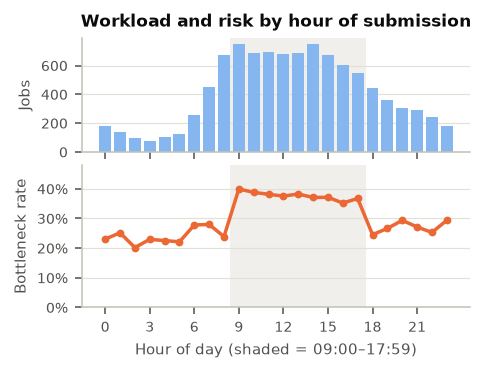

Bottleneck rate off-peak: 25.8%   peak: 37.7%


In [19]:
hourly = df.groupby("submit_hour").agg(jobs=("job_id", "size"), rate=("is_bottleneck", "mean"))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=HALF, sharex=True, gridspec_kw={"height_ratios": [1, 1.25]})
ax1.bar(hourly.index, hourly["jobs"], color=BLUE_LIGHT, width=0.8)
ax1.set_ylabel("Jobs"); ax1.set_title("Workload and risk by hour of submission")
ax2.plot(hourly.index, hourly["rate"], color=ORANGE, marker="o", ms=3)
for ax in (ax1, ax2):
    ax.axvspan(8.5, 17.5, color="#f0efec", zorder=0); ax.grid(axis="x", visible=False)
ax2.set_ylim(0, hourly["rate"].max() * 1.2); ax2.yaxis.set_major_formatter(PCT)
ax2.set_ylabel("Bottleneck rate"); ax2.set_xlabel("Hour of day (shaded = 09:00–17:59)"); ax2.set_xticks(range(0, 24, 3))
fig.tight_layout(h_pad=0.3); save(fig, "fig_hourly_pattern"); plt.show()
peak_rate = df.groupby("is_peak_hour")["is_bottleneck"].mean()
print(f"Bottleneck rate off-peak: {peak_rate[0]:.1%}   peak: {peak_rate[1]:.1%}")

### 5.4 Distribution of key telemetry by class

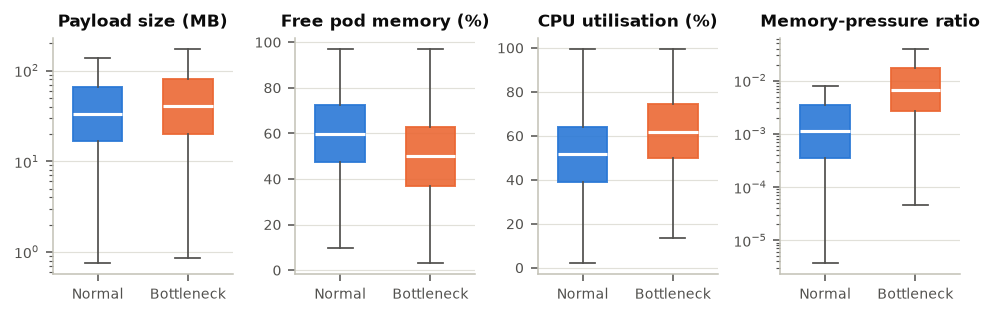

target_label,Bottleneck,Normal
payload_size_mb,40.5600,33.0550
pod_memory_available_pct,49.9000,59.5000
cpu_utilization_pct,61.7500,51.7000
memory_pressure_ratio,0.0067,0.0011
threads_per_vcpu,4.0000,1.2500
queue_wait_time_ms,98.6500,72.6500
gc_pause_time_ms,45.2500,29.8500


In [20]:
panels = [("payload_size_mb", "Payload size (MB)", True), ("pod_memory_available_pct", "Free pod memory (%)", False),
          ("cpu_utilization_pct", "CPU utilisation (%)", False), ("memory_pressure_ratio", "Memory-pressure ratio", True)]
fig, axes = plt.subplots(1, 4, figsize=(FULL, 2.3))
for ax, (col, title, logy) in zip(axes, panels):
    bp = ax.boxplot([df.loc[df["target_label"] == k, col] for k in ["Normal", "Bottleneck"]],
                    widths=0.55, patch_artist=True, showfliers=False)
    style_box(bp, [BLUE, ORANGE])
    ax.set_xticks([1, 2], ["Normal", "Bottleneck"])
    if logy:
        ax.set_yscale("log")
    ax.set_title(title); ax.grid(axis="x", visible=False)
fig.tight_layout(w_pad=1.0); save(fig, "fig_class_boxplots"); plt.show()
df.groupby("target_label")[["payload_size_mb", "pod_memory_available_pct", "cpu_utilization_pct", "memory_pressure_ratio",
                            "threads_per_vcpu", "queue_wait_time_ms", "gc_pause_time_ms"]].median().T.round(4)

### 5.5 Correlation analysis and CPU / memory interaction

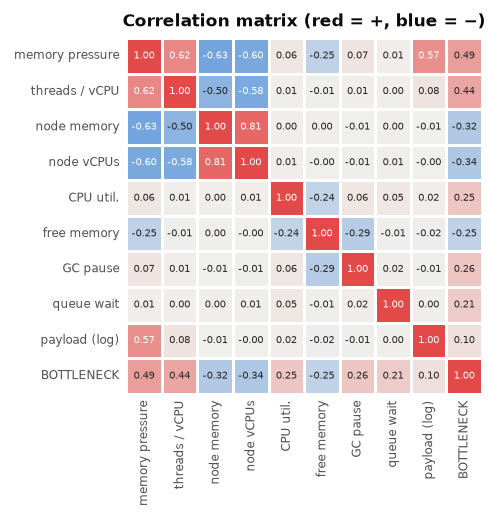

memory_pressure_log         0.490
threads_per_vcpu            0.438
node_vcpus_n               -0.336
node_memory_gib            -0.319
gc_pause_time_ms            0.257
pod_memory_available_pct   -0.249
cpu_utilization_pct         0.247
queue_wait_time_ms          0.213
payload_size_mb_log         0.099
Name: is_bottleneck, dtype: float64

In [21]:
corr_names = {"memory_pressure_log": "memory pressure", "threads_per_vcpu": "threads / vCPU", "node_memory_gib": "node memory",
              "node_vcpus_n": "node vCPUs", "cpu_utilization_pct": "CPU util.", "pod_memory_available_pct": "free memory",
              "gc_pause_time_ms": "GC pause", "queue_wait_time_ms": "queue wait", "payload_size_mb_log": "payload (log)",
              "is_bottleneck": "BOTTLENECK"}
corr = df[list(corr_names)].corr()
fig, ax = plt.subplots(figsize=(3.5, 3.3))
sns.heatmap(corr.rename(index=corr_names, columns=corr_names), cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=True,
            fmt=".2f", annot_kws={"size": 5.3}, linewidths=0.6, linecolor="white", cbar=False, square=True, ax=ax)
ax.grid(False); ax.tick_params(labelsize=6.2, length=0); ax.set_title("Correlation matrix (red = +, blue = −)")
save(fig, "fig_correlation"); plt.show()
corr["is_bottleneck"].drop("is_bottleneck").sort_values(key=abs, ascending=False).round(3)

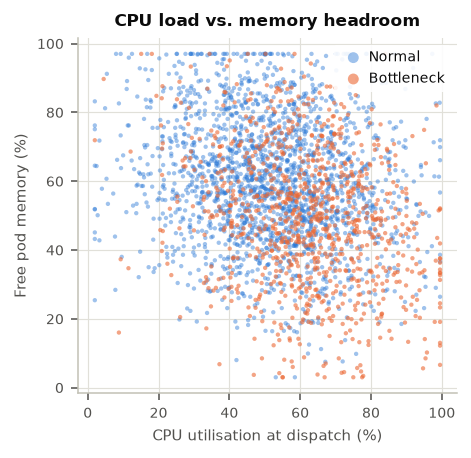

In [22]:
sample = df.sample(3000, random_state=SEED)
fig, ax = plt.subplots(figsize=(3.5, 3.3))
for k, a in [("Normal", 0.45), ("Bottleneck", 0.6)]:
    g = sample[sample["target_label"] == k]
    ax.scatter(g["cpu_utilization_pct"], g["pod_memory_available_pct"], s=5, alpha=a, c=CLASS_COLORS[k], edgecolors="none", label=k)
ax.set_xlabel("CPU utilisation at dispatch (%)"); ax.set_ylabel("Free pod memory (%)")
ax.set_title("CPU load vs. memory headroom")
ax.legend(markerscale=2.5, loc="upper right", handletextpad=0.1, frameon=True, facecolor="white", edgecolor="none", framealpha=0.9)
save(fig, "fig_cpu_memory_scatter"); plt.show()

### 5.6 Memory pressure and node size (scraped capacity)

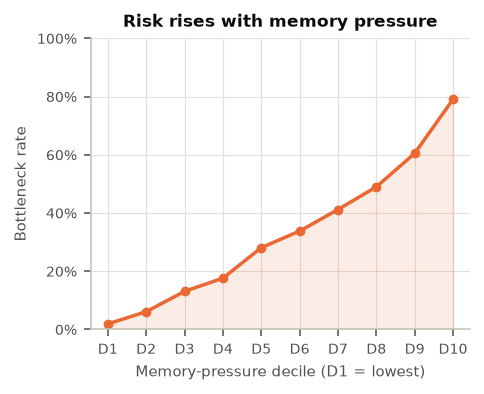

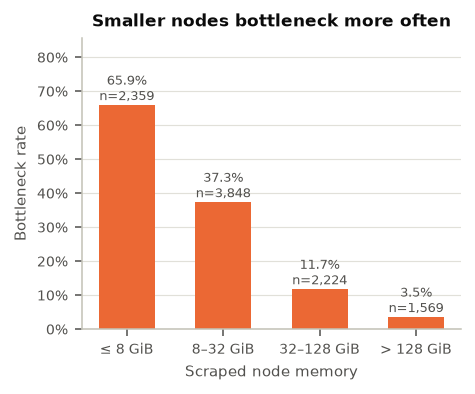

{'D1': 0.019, 'D2': 0.061, 'D3': 0.131, 'D4': 0.176, 'D5': 0.281, 'D6': 0.338, 'D7': 0.412, 'D8': 0.49, 'D9': 0.605, 'D10': 0.791}


,mean,size
node_memory_tier,,
≤ 8 GiB,0.659,2359
8–32 GiB,0.373,3848
32–128 GiB,0.117,2224
> 128 GiB,0.035,1569


In [23]:
df["pressure_decile"] = pd.qcut(df["memory_pressure_ratio"], 10, labels=[f"D{i}" for i in range(1, 11)])
by_decile = df.groupby("pressure_decile", observed=True)["is_bottleneck"].mean()
df["node_memory_tier"] = pd.cut(df["node_memory_gib"], [0, 8, 32, 128, 1024],
                                labels=["≤ 8 GiB", "8–32 GiB", "32–128 GiB", "> 128 GiB"])
by_tier = df.groupby("node_memory_tier", observed=True)["is_bottleneck"].agg(["mean", "size"])

fig, ax = plt.subplots(figsize=HALF)
ax.plot(range(1, 11), by_decile.values, marker="o", ms=4, color=ORANGE)
ax.fill_between(range(1, 11), by_decile.values, color=ORANGE, alpha=0.12)
ax.set_xticks(range(1, 11), [f"D{i}" for i in range(1, 11)]); ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(PCT)
ax.set_xlabel("Memory-pressure decile (D1 = lowest)"); ax.set_ylabel("Bottleneck rate")
ax.set_title("Risk rises with memory pressure")
save(fig, "fig_memory_pressure"); plt.show()

fig, ax = plt.subplots(figsize=HALF)
b = ax.bar(by_tier.index.astype(str), by_tier["mean"], color=ORANGE, width=0.58)
for bar, (m, n) in zip(b, by_tier.values):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 0.015, f"{m:.1%}\nn={int(n):,}", ha="center", fontsize=6.6, color=INK2)
ax.set_ylim(0, by_tier["mean"].max() * 1.3); ax.yaxis.set_major_formatter(PCT); ax.set_ylabel("Bottleneck rate")
ax.set_xlabel("Scraped node memory"); ax.set_title("Smaller nodes bottleneck more often"); ax.grid(axis="x", visible=False)
save(fig, "fig_node_memory_tier"); plt.show()
print(by_decile.round(3).to_dict()); by_tier.round(3)

### 5.7 Cost impact of bottlenecks (cloud cost spikes)

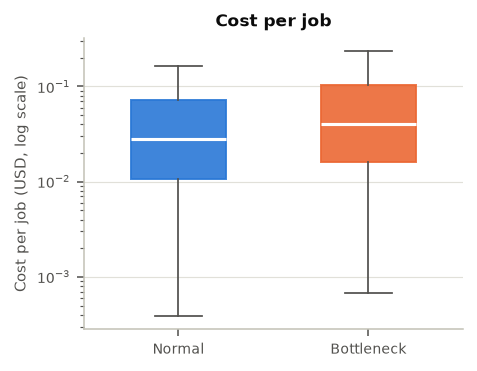

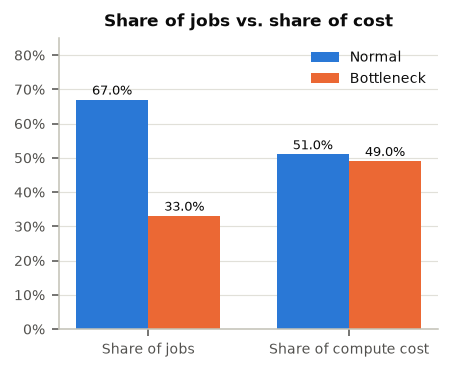

,jobs,total_cost,median_cost,median_runtime,job_share,cost_share
target_label,,,,,,
Bottleneck,3304,407.5587,0.0406,303.85,0.3304,0.4902
Normal,6696,423.8727,0.0283,50.00,0.6696,0.5098


In [24]:
cost = df.groupby("target_label").agg(jobs=("job_id", "size"), total_cost=("job_cost_usd", "sum"),
                                      median_cost=("job_cost_usd", "median"), median_runtime=("execution_time_sec", "median"))
cost["job_share"] = cost["jobs"] / cost["jobs"].sum()
cost["cost_share"] = cost["total_cost"] / cost["total_cost"].sum()

fig, ax = plt.subplots(figsize=HALF)
bp = ax.boxplot([df.loc[df["target_label"] == k, "job_cost_usd"] for k in ["Normal", "Bottleneck"]],
                widths=0.5, patch_artist=True, showfliers=False)
style_box(bp, [BLUE, ORANGE])
ax.set_xticks([1, 2], ["Normal", "Bottleneck"]); ax.set_yscale("log")
ax.set_ylabel("Cost per job (USD, log scale)"); ax.set_title("Cost per job"); ax.grid(axis="x", visible=False)
save(fig, "fig_cost_per_job"); plt.show()

fig, ax = plt.subplots(figsize=HALF)
x = np.arange(2); w = 0.36
for i, k in enumerate(["Normal", "Bottleneck"]):
    vals = [cost.loc[k, "job_share"], cost.loc[k, "cost_share"]]
    bars = ax.bar(x + (i - 0.5) * w, vals, w, color=CLASS_COLORS[k], label=k)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.1%}", ha="center", fontsize=6.8, color=INK)
ax.set_xticks(x, ["Share of jobs", "Share of compute cost"]); ax.set_ylim(0, 0.85); ax.yaxis.set_major_formatter(PCT)
ax.set_title("Share of jobs vs. share of cost"); ax.legend(loc="upper right"); ax.grid(axis="x", visible=False)
save(fig, "fig_cost_share"); plt.show()
cost.round(4)

In [25]:
spot_df = df.dropna(subset=["node_spot_price_usd_hr"])
spot_saving = 1 - (spot_df["job_cost_usd"] * spot_df["node_spot_price_usd_hr"] / spot_df["node_price_usd_hr"]).sum() / spot_df["job_cost_usd"].sum()
low_pri = spot_df[spot_df["priority_level"] == "Low"]
low_share = low_pri["job_cost_usd"].sum() / df["job_cost_usd"].sum()
print(f"Average saving if jobs ran on the scraped minimum spot price instead of on-demand: {spot_saving:.1%}")
print(f"Low-priority jobs account for {low_share:.1%} of total spend (candidates for spot capacity)")

Average saving if jobs ran on the scraped minimum spot price instead of on-demand: 67.0%
Low-priority jobs account for 30.9% of total spend (candidates for spot capacity)


## 6. Predictive Modelling

**Leakage control:** `execution_time_sec` and `job_cost_usd` are only known *after* a job finishes and are
consequences of the bottleneck, so they are excluded from the model. Only information available at submission time
(job profile, scraped node specification/price, node state at assignment) is used.

**Methods (Business Analytics syllabus – classification):** Logistic Regression (interpretable baseline),
Decision Tree (rule-based, explainable) and Random Forest (ensemble of trees). Hyper-parameters of the tree models are
tuned with 5-fold stratified cross-validation on the training set; the test set (25 %) is used only once for the
final evaluation. Class weights are balanced because missing a bottleneck is costlier than a false alarm.

In [26]:
num_features = ["payload_size_mb_log", "executor_memory_mb", "replica_count", "retry_count", "node_vcpus_n",
                "node_memory_gib", "node_price_usd_hr", "node_network_gbps", "node_network_burst",
                "cpu_utilization_pct", "pod_memory_available_pct", "active_thread_count", "broker_latency_ms",
                "queue_wait_time_ms", "disk_io_mbps", "network_io_mbps", "gc_pause_time_ms", "submit_hour",
                "is_peak_hour", "memory_pressure_log", "threads_per_vcpu", "memory_per_vcpu_gib"]
cat_features = ["job_category", "priority_level", "region", "node_family"]
y = df["is_bottleneck"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
])
# trees are insensitive to scaling and monotone transforms, so they use raw units (readable split rules)
tree_num_features = [{"payload_size_mb_log": "payload_size_mb", "memory_pressure_log": "memory_pressure_ratio"}.get(f, f)
                     for f in num_features]
preprocess_tree = ColumnTransformer([
    ("num", "passthrough", tree_num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
])
X = df[num_features + ["payload_size_mb", "memory_pressure_ratio"] + cat_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
print(f"Model features: {len(num_features)} numeric + {len(cat_features)} categorical")
print(f"Training set: {len(X_train):,} jobs, bottleneck share {y_train.mean():.3f}")
print(f"Test set:     {len(X_test):,} jobs, bottleneck share {y_test.mean():.3f}")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Model features: 22 numeric + 4 categorical
Training set: 7,500 jobs, bottleneck share 0.330
Test set:     2,500 jobs, bottleneck share 0.330


In [27]:
log_reg = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED))])

tree_search = GridSearchCV(
    Pipeline([("prep", preprocess_tree), ("model", DecisionTreeClassifier(class_weight="balanced", random_state=SEED))]),
    {"model__max_depth": [4, 6, 8, 10], "model__min_samples_leaf": [20, 50, 100]}, scoring="roc_auc", cv=cv, n_jobs=-1)
tree_search.fit(X_train, y_train)
print("Decision Tree best parameters:", tree_search.best_params_, " CV ROC-AUC:", round(tree_search.best_score_, 4))

forest_search = GridSearchCV(
    Pipeline([("prep", preprocess_tree), ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=SEED))]),
    {"model__max_depth": [10, 16, None], "model__min_samples_leaf": [2, 5, 10]}, scoring="roc_auc", cv=cv, n_jobs=-1)
forest_search.fit(X_train, y_train)
print("Random Forest best parameters:", forest_search.best_params_, " CV ROC-AUC:", round(forest_search.best_score_, 4))

models = {"Logistic Regression": log_reg, "Decision Tree": tree_search.best_estimator_, "Random Forest": forest_search.best_estimator_}

Decision Tree best parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 50}  CV ROC-AUC: 0.8674


Random Forest best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2}  CV ROC-AUC: 0.915


In [28]:
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}
cv_rows = {}
for name, model in models.items():
    s = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows[name] = {m: s[f"test_{m}"].mean() for m in scoring} | {"roc_auc_sd": s["test_roc_auc"].std()}
cv_table = pd.DataFrame(cv_rows).T
print("5-fold cross-validation on the training set (mean):")
cv_table.round(4)

5-fold cross-validation on the training set (mean):


,accuracy,precision,recall,f1,roc_auc,roc_auc_sd
Logistic Regression,0.8504,0.7342,0.8592,0.7915,0.9398,0.0026
Decision Tree,0.7765,0.6293,0.7938,0.7015,0.8674,0.0085
Random Forest,0.8335,0.7227,0.8051,0.7616,0.9150,0.0063


## 7. Model Evaluation on the Hold-out Test Set

In [29]:
test_rows, probas = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)
    probas[name] = p
    test_rows[name] = {"accuracy": accuracy_score(y_test, pred), "precision": precision_score(y_test, pred),
                       "recall": recall_score(y_test, pred), "f1": f1_score(y_test, pred), "roc_auc": roc_auc_score(y_test, p)}
test_table = pd.DataFrame(test_rows).T.sort_values("roc_auc", ascending=False)
best_name = cv_table["roc_auc"].idxmax()
print("Model selected by cross-validated ROC-AUC:", best_name)
test_table.round(4)

Model selected by cross-validated ROC-AUC: Logistic Regression


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8592,0.7448,0.8729,0.8038,0.9471
Random Forest,0.8452,0.7348,0.8317,0.7802,0.9267
Decision Tree,0.7736,0.6186,0.8208,0.7055,0.8718


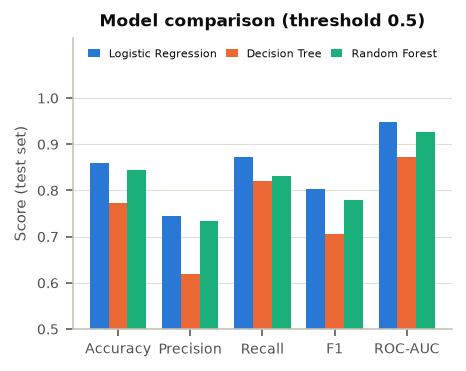

In [30]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
fig, ax = plt.subplots(figsize=HALF)
x = np.arange(len(metrics)); w = 0.26
for i, name in enumerate(MODEL_COLORS):
    ax.bar(x + (i - 1) * w, test_table.loc[name, metrics].values, w, color=MODEL_COLORS[name], label=name)
ax.set_xticks(x, ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]); ax.set_ylim(0.5, 1.13)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]); ax.set_ylabel("Score (test set)")
ax.set_title("Model comparison (threshold 0.5)"); ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", ncol=3, fontsize=5.9, handlelength=1, columnspacing=0.8)
save(fig, "fig_model_comparison"); plt.show()

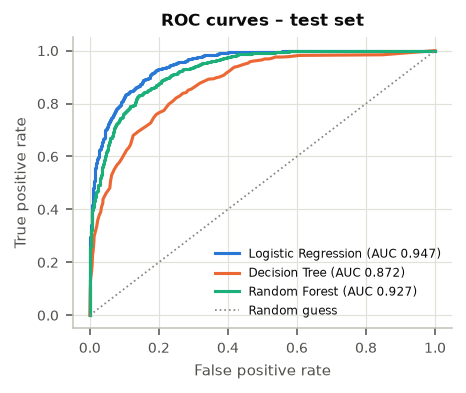

In [31]:
fig, ax = plt.subplots(figsize=HALF)
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], lw=1.6, label=f"{name} (AUC {roc_auc_score(y_test, p):.3f})")
ax.plot([0, 1], [0, 1], color=GREY, lw=0.9, ls=":", label="Random guess")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves – test set"); ax.legend(loc="lower right", fontsize=6.2)
save(fig, "fig_roc"); plt.show()

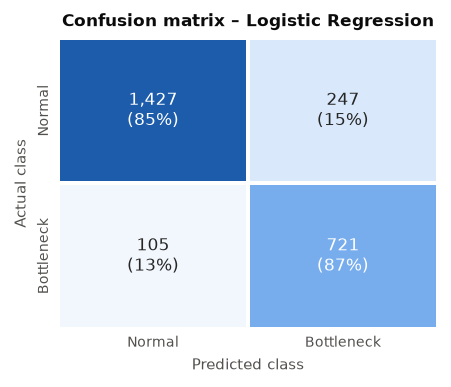

              precision    recall  f1-score   support

      Normal      0.931     0.852     0.890      1674
  Bottleneck      0.745     0.873     0.804       826

    accuracy                          0.859      2500
   macro avg      0.838     0.863     0.847      2500
weighted avg      0.870     0.859     0.862      2500



In [32]:
best_model = models[best_name]
best_p = probas[best_name]
cm = confusion_matrix(y_test, (best_p >= 0.5).astype(int))
row_pct = cm / cm.sum(axis=1, keepdims=True)
annot = np.array([[f"{cm[i, j]:,}\n({row_pct[i, j]:.0%})" for j in range(2)] for i in range(2)])
fig, ax = plt.subplots(figsize=HALF)
sns.heatmap(cm, annot=annot, fmt="", cmap=BLUE_RAMP, cbar=False, linewidths=2, linecolor="white",
            xticklabels=["Normal", "Bottleneck"], yticklabels=["Normal", "Bottleneck"], annot_kws={"size": 8.5}, ax=ax)
ax.grid(False); ax.tick_params(length=0)
ax.set_xlabel("Predicted class"); ax.set_ylabel("Actual class"); ax.set_title(f"Confusion matrix – {best_name}")
save(fig, "fig_confusion"); plt.show()
print(classification_report(y_test, (best_p >= 0.5).astype(int), target_names=["Normal", "Bottleneck"], digits=3))

### 7.1 Which factors drive the risk?

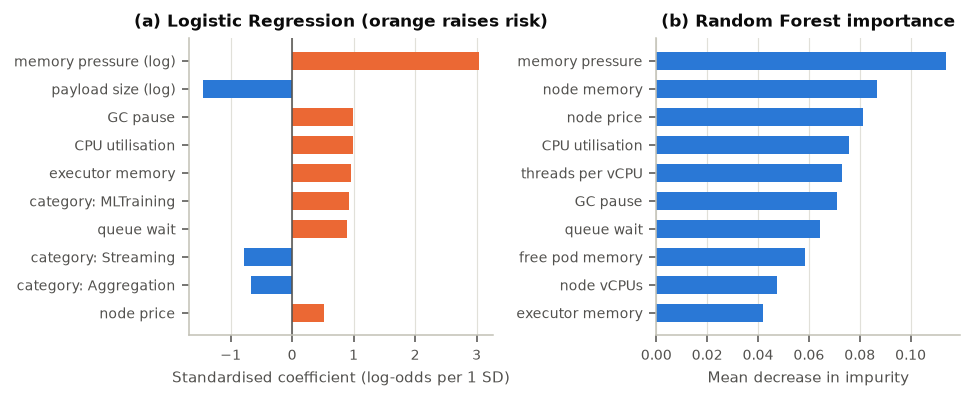

Note: payload_size_mb_log has a negative coefficient only because memory_pressure_log already contains the payload
(correlation between the two: 0.575 ).
Holding memory pressure fixed, a larger payload implies a larger node, so the two coefficients must be read together.


,LR coefficient,odds ratio (per SD)
memory_pressure_log,3.043,20.97
payload_size_mb_log,-1.453,0.23
gc_pause_time_ms,0.991,2.69
cpu_utilization_pct,0.987,2.68
executor_memory_mb,0.962,2.62
job_category_MLTraining,0.931,2.54
queue_wait_time_ms,0.899,2.46
job_category_Streaming,-0.775,0.46
job_category_Aggregation,-0.663,0.52
node_price_usd_hr,0.517,1.68


In [33]:
NICE = {"memory_pressure_log": "memory pressure (log)", "memory_pressure_ratio": "memory pressure",
        "payload_size_mb_log": "payload size (log)", "payload_size_mb": "payload size", "gc_pause_time_ms": "GC pause",
        "cpu_utilization_pct": "CPU utilisation", "executor_memory_mb": "executor memory", "queue_wait_time_ms": "queue wait",
        "node_price_usd_hr": "node price", "retry_count": "retry count", "node_memory_gib": "node memory",
        "threads_per_vcpu": "threads per vCPU", "pod_memory_available_pct": "free pod memory", "node_vcpus_n": "node vCPUs",
        "broker_latency_ms": "broker latency", "active_thread_count": "active threads", "replica_count": "replicas",
        "memory_per_vcpu_gib": "memory per vCPU", "disk_io_mbps": "disk I/O", "network_io_mbps": "network I/O"}
def nice(name):
    for prefix, label in [("job_category_", "category: "), ("priority_level_", "priority: "), ("region_", "region: "), ("node_family_", "family: ")]:
        if name.startswith(prefix):
            return label + name[len(prefix):]
    return NICE.get(name, name)

lr_fitted = models["Logistic Regression"]
coef = pd.Series(lr_fitted.named_steps["model"].coef_[0], index=lr_fitted.named_steps["prep"].get_feature_names_out())
coef.index = coef.index.str.replace("num__", "").str.replace("cat__", "")
top_coef = coef.reindex(coef.abs().sort_values(ascending=False).index).head(12)

rf_fitted = models["Random Forest"]
imp = pd.Series(rf_fitted.named_steps["model"].feature_importances_, index=rf_fitted.named_steps["prep"].get_feature_names_out())
imp.index = imp.index.str.replace("num__", "").str.replace("cat__", "")
top_imp = imp.sort_values(ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(FULL, 2.9))
c10 = top_coef.head(10)[::-1]
axes[0].barh([nice(n) for n in c10.index], c10.values, color=[ORANGE if v > 0 else BLUE for v in c10.values], height=0.65)
axes[0].axvline(0, color=INK2, lw=0.8); axes[0].set_xlabel("Standardised coefficient (log-odds per 1 SD)")
axes[0].set_title("(a) Logistic Regression (orange raises risk)"); axes[0].grid(axis="y", visible=False)
i10 = top_imp.head(10)[::-1]
axes[1].barh([nice(n) for n in i10.index], i10.values, color=BLUE, height=0.65)
axes[1].set_xlabel("Mean decrease in impurity"); axes[1].set_title("(b) Random Forest importance"); axes[1].grid(axis="y", visible=False)
fig.tight_layout(w_pad=1.5); save(fig, "fig_feature_importance"); plt.show()
print("Note: payload_size_mb_log has a negative coefficient only because memory_pressure_log already contains the payload")
print("(correlation between the two:", round(df[["payload_size_mb_log", "memory_pressure_log"]].corr().iloc[0, 1], 3), ").")
print("Holding memory pressure fixed, a larger payload implies a larger node, so the two coefficients must be read together.")
pd.DataFrame({"LR coefficient": top_coef.round(3)}).join(pd.DataFrame({"odds ratio (per SD)": np.exp(top_coef).round(2)}))

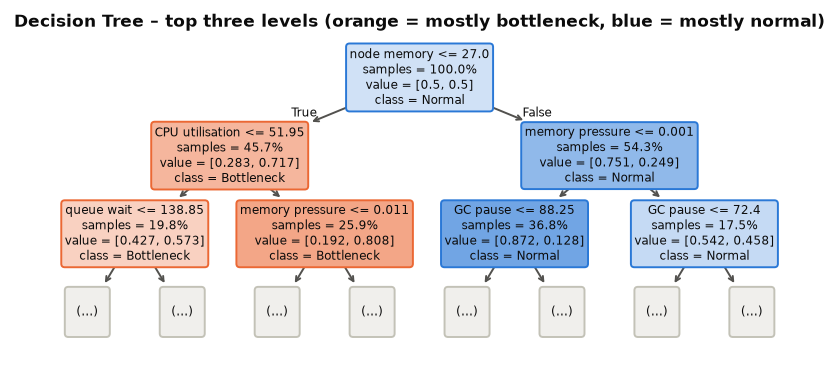

In [34]:
import re
from matplotlib.colors import to_rgb

def tint(color, strength):
    c = np.array(to_rgb(color))
    return tuple(1 - (1 - c) * strength)

tree_fitted = models["Decision Tree"]
tree_names = [nice(n.replace("num__", "").replace("cat__", "")) for n in tree_fitted.named_steps["prep"].get_feature_names_out()]
fig, ax = plt.subplots(figsize=(FULL, 2.9))
nodes_drawn = plot_tree(tree_fitted.named_steps["model"], max_depth=2, feature_names=tree_names, class_names=["Normal", "Bottleneck"],
                        filled=True, impurity=False, proportion=True, rounded=True, fontsize=6, ax=ax)
fig.canvas.draw()
for ann in nodes_drawn:
    box = ann.get_bbox_patch()
    if box is None:
        continue
    m = re.search(r"value = \[([0-9.]+), ([0-9.]+)\]", ann.get_text())
    if m:
        p_normal, p_bottleneck = float(m.group(1)), float(m.group(2))
        col = ORANGE if p_bottleneck > p_normal else BLUE
        box.set_facecolor(tint(col, 0.22 + 0.6 * abs(p_bottleneck - p_normal))); box.set_edgecolor(col)
    else:
        box.set_facecolor("#f0efec"); box.set_edgecolor(AXIS)
    if ann.arrow_patch is not None:
        ann.arrow_patch.set_color(INK2)
ax.set_title("Decision Tree – top three levels (orange = mostly bottleneck, blue = mostly normal)")
save(fig, "fig_decision_tree"); plt.show()

### 7.2 Choosing the operating threshold

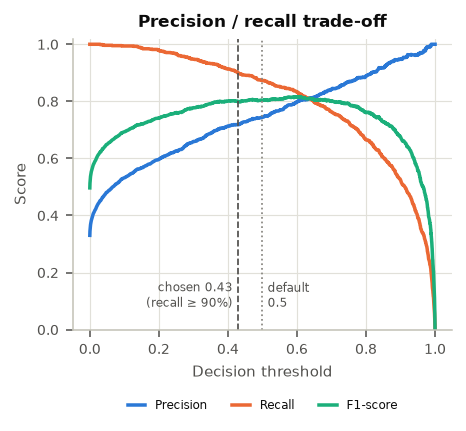

Operating threshold 0.429: recall 0.901, precision 0.719, flagged 41.4% of jobs


In [35]:
prec, rec, thr = precision_recall_curve(y_test, best_p)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1])
target_recall = 0.90
op_idx = np.where(rec[:-1] >= target_recall)[0][-1]
op_thr = thr[op_idx]

fig, ax = plt.subplots(figsize=HALF)
ax.plot(thr, prec[:-1], color=BLUE, label="Precision"); ax.plot(thr, rec[:-1], color=ORANGE, label="Recall")
ax.plot(thr, f1s, color=AQUA, label="F1-score")
ax.axvline(0.5, color=GREY, lw=0.9, ls=":"); ax.text(0.515, 0.08, "default\n0.5", fontsize=6.4, color=INK2)
ax.axvline(op_thr, color=INK2, lw=0.9, ls="--"); ax.text(op_thr - 0.015, 0.08, f"chosen {op_thr:.2f}\n(recall ≥ 90%)", fontsize=6.4, color=INK2, ha="right")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.02)
ax.set_title("Precision / recall trade-off")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=6.4, handlelength=1.4)
save(fig, "fig_threshold"); plt.show()

op_pred = (best_p >= op_thr).astype(int)
print(f"Operating threshold {op_thr:.3f}: recall {recall_score(y_test, op_pred):.3f}, precision {precision_score(y_test, op_pred):.3f}, "
      f"flagged {op_pred.mean():.1%} of jobs")

## 8. Business Impact of the Early-Warning Model

In [36]:
test_df = df.loc[X_test.index].assign(p_risk=best_p, flagged=op_pred)
bn = test_df[test_df["is_bottleneck"] == 1]
caught_cost_share = bn.loc[bn["flagged"] == 1, "job_cost_usd"].sum() / bn["job_cost_usd"].sum()
median_ratio = cost.loc["Bottleneck", "median_cost"] / cost.loc["Normal", "median_cost"]
runtime_ratio = cost.loc["Bottleneck", "median_runtime"] / cost.loc["Normal", "median_runtime"]
high_pressure_rate = df.loc[df["pressure_decile"].isin(["D9", "D10"]), "is_bottleneck"].mean()
low_pressure_rate = df.loc[df["pressure_decile"].isin(["D1", "D2"]), "is_bottleneck"].mean()
cpu_hot = df.loc[df["cpu_utilization_pct"] >= 75, "is_bottleneck"].mean()
cpu_cool = df.loc[df["cpu_utilization_pct"] < 40, "is_bottleneck"].mean()
print(f"Bottleneck jobs: median cost {median_ratio:.2f}x and median runtime {runtime_ratio:.2f}x those of normal jobs")
print(f"At the operating threshold the model flags bottleneck jobs responsible for {caught_cost_share:.1%} of bottleneck spend (test set)")
print(f"Bottleneck rate in top-2 memory-pressure deciles: {high_pressure_rate:.1%} vs bottom-2 deciles: {low_pressure_rate:.1%}")
print(f"Bottleneck rate when node CPU >= 75%: {cpu_hot:.1%} vs < 40%: {cpu_cool:.1%}")

Bottleneck jobs: median cost 1.44x and median runtime 6.08x those of normal jobs
At the operating threshold the model flags bottleneck jobs responsible for 83.4% of bottleneck spend (test set)
Bottleneck rate in top-2 memory-pressure deciles: 69.8% vs bottom-2 deciles: 4.0%
Bottleneck rate when node CPU >= 75%: 52.8% vs < 40%: 17.6%


In [37]:
results = {
    "raw_rows": int(len(raw)), "raw_cols": int(raw.shape[1]), "duplicates_removed": n_dup, "clean_rows": int(len(df)),
    "category_fixes": n_fixed_cat, "region_fixes": n_fixed_region, "bad_cpu": int(bad_cpu.sum()), "bad_latency": int(bad_lat.sum()),
    "missing": {k: int(v) for k, v in missing.items()}, "n_node_types": int(df["node_instance_type"].nunique()),
    "class_share": df["target_label"].value_counts(normalize=True).round(4).to_dict(),
    "rate_by_category": rate_cat["mean"].round(4).to_dict(), "rate_by_priority": rate_pri["mean"].round(4).to_dict(),
    "rate_by_memory_tier": by_tier["mean"].round(4).to_dict(), "rate_by_pressure_decile": by_decile.round(4).to_dict(),
    "peak_rate": float(peak_rate[1]), "offpeak_rate": float(peak_rate[0]),
    "cost_table": cost.round(6).to_dict(orient="index"), "spot_saving": float(spot_saving), "low_priority_cost_share": float(low_share),
    "tree_params": tree_search.best_params_, "forest_params": forest_search.best_params_,
    "cv_table": cv_table.round(4).to_dict(orient="index"), "test_table": test_table.round(4).to_dict(orient="index"),
    "best_model": best_name, "confusion_matrix": cm.tolist(), "op_threshold": float(op_thr),
    "op_recall": float(recall_score(y_test, op_pred)), "op_precision": float(precision_score(y_test, op_pred)),
    "op_flag_rate": float(op_pred.mean()), "caught_cost_share": float(caught_cost_share),
    "median_cost_ratio": float(median_ratio), "median_runtime_ratio": float(runtime_ratio),
    "high_pressure_rate": float(high_pressure_rate), "low_pressure_rate": float(low_pressure_rate),
    "cpu_hot_rate": float(cpu_hot), "cpu_cool_rate": float(cpu_cool),
    "top_lr_coef": top_coef.round(4).to_dict(), "top_rf_imp": top_imp.round(4).to_dict(),
    "corr_with_target": corr["is_bottleneck"].drop("is_bottleneck").round(4).to_dict(),
    "class_medians": df.groupby("target_label")[["payload_size_mb", "pod_memory_available_pct", "cpu_utilization_pct",
        "memory_pressure_ratio", "threads_per_vcpu", "queue_wait_time_ms", "gc_pause_time_ms", "node_memory_gib",
        "node_vcpus_n", "node_price_usd_hr", "execution_time_sec", "job_cost_usd"]].median().round(5).to_dict(orient="index"),
    "time_span": [str(ts.min()), str(ts.max())],
    "outliers": {k: int(v) for k, v in outlier_table["IQR outliers"].items()},
    "node_price_range": [float(nodes["node_price_usd_hr"].min()), float(nodes["node_price_usd_hr"].max())],
    "node_memory_range": [float(nodes["node_memory_gib"].min()), float(nodes["node_memory_gib"].max())],
    "total_cost": float(df["job_cost_usd"].sum()),
    "payload_corr_pressure": float(df[["payload_size_mb_log", "memory_pressure_log"]].corr().iloc[0, 1]),
}
Path("results_summary.json").write_text(json.dumps(results, indent=2, default=str))
print("Key results saved to results_summary.json")

Key results saved to results_summary.json


## 9. Business Insights and Recommendations

1. **Memory headroom relative to payload is the dominant risk driver.** The bottleneck rate climbs steeply across
   memory-pressure deciles, and small nodes (≤ 8 GiB, taken from the scraped catalogue) bottleneck far more often than
   large ones. *Recommendation:* the scheduler should compute the payload-to-free-memory ratio at dispatch time and
   route high-ratio jobs to memory-optimised nodes instead of the first free node.
2. **A busy CPU at assignment time multiplies the risk.** Jobs dispatched to nodes already above ~75 % CPU are far more
   likely to bottleneck. *Recommendation:* add a CPU-utilisation admission rule (queue or reroute when CPU ≥ 75 %).
3. **ML-training and web-scraping jobs are the riskiest categories**, while streaming and aggregation jobs are low
   risk. *Recommendation:* give the two risky categories a dedicated, larger node pool and pack low-risk categories
   tightly on small, cheap nodes.
4. **Bottlenecks create the cost spikes.** Bottleneck jobs run several times longer and consume a share of compute spend
   well above their share of jobs. *Recommendation:* use the model's risk score to reserve buffer capacity only for the
   flagged subset instead of over-provisioning the entire cluster.
5. **The early-warning model is deployable.** With the operating threshold tuned for ≥ 90 % recall, the model flags
   most bottleneck jobs (and most of the bottleneck spend) before they run. *Recommendation:* integrate the model as a
   pre-dispatch check and retrain monthly on fresh logs.
6. **Cheaper capacity for tolerant work.** Scraped spot prices are far below on-demand prices; low-priority jobs are
   candidates for spot capacity.

## 10. Conclusion

A dataset of 10,000 job-execution records, built on 1,413 scraped real cloud instance types, was cleaned, explored and
modelled. The selected classifier separates bottleneck jobs from normal jobs with high discrimination using only
pre-execution information, and the drivers it relies on (memory pressure, CPU load, thread density, job category)
agree with the exploratory analysis. **Limitation:** the job telemetry is simulated because real production logs are
confidential; the node specifications and prices are real, but the numerical thresholds should be re-estimated on a
company's own logs before deployment.

## Appendix A – Data collection code

The two scripts below (also in the `scripts/` folder) were used to create `data/cloud_job_execution_dataset.csv`. They are included for transparency and
reproducibility; set `RUN_COLLECTION = True` to re-run the collection (requires Google Chrome and Internet access).

### A.1 Stage 1 – web scraping of the instance catalogue (`scrape_instance_catalogue.py`)

In [38]:
RUN_COLLECTION = False

"""
Stage 1 of data collection: web scraping of the public cloud instance catalogue.

Source: https://instances.vantage.sh/ (publicly accessible AWS EC2 instance comparison page).
The table is rendered client-side by JavaScript and virtualised (only rows inside the
viewport exist in the DOM), so the page is rendered in headless Chrome with a very tall
viewport, the rendered DOM is dumped, and the <table> is parsed with BeautifulSoup.

Output: data/raw/scraped_instance_catalogue.csv  (values kept exactly as displayed on the page)
"""

import os
import shlex
import subprocess
from datetime import datetime, timezone

import pandas as pd
from bs4 import BeautifulSoup

URL = "https://instances.vantage.sh/"
CHROME_BIN = os.environ.get("CHROME_BIN", "google-chrome")
RAW_HTML = "data/raw/instances_vantage_rendered.html"
SCREENSHOT = "data/raw/instances_vantage_screenshot.png"
OUT_CSV = "data/raw/scraped_instance_catalogue.csv"

COLUMNS = [
    "instance_name", "api_name", "coremark_score", "compute_family", "ffmpeg_fps",
    "instance_memory", "vcpus", "instance_storage", "network_performance",
    "linux_on_demand", "linux_reserved", "linux_spot_min", "windows_on_demand", "windows_reserved",
]


def chrome(*args):
    cmd = shlex.split(CHROME_BIN) + ["--headless=new", "--disable-gpu", "--no-sandbox", *args, URL]
    return subprocess.run(cmd, capture_output=True, text=True, timeout=300)


def render_page():
    result = chrome("--window-size=1600,60000", "--virtual-time-budget=30000", "--dump-dom")
    os.makedirs(os.path.dirname(RAW_HTML), exist_ok=True)
    with open(RAW_HTML, "w", encoding="utf-8") as f:
        f.write(result.stdout)
    chrome("--window-size=1600,1000", "--virtual-time-budget=15000", f"--screenshot={os.path.abspath(SCREENSHOT)}")
    return result.stdout


def parse_table(html):
    table = BeautifulSoup(html, "html.parser").find("table")
    records = []
    for row in table.find_all("tr"):
        cells = [td.get_text(" ", strip=True) for td in row.find_all("td")]
        if len(cells) < len(COLUMNS) or not cells[1]:
            continue  # header row / empty spacer rows of the virtualised table
        records.append(dict(zip(COLUMNS, cells[: len(COLUMNS)])))
    return pd.DataFrame(records)


def main():
    html = render_page()
    df = parse_table(html)
    df = df.drop_duplicates(subset="api_name").reset_index(drop=True)
    df["scraped_at_utc"] = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M")
    df.to_csv(OUT_CSV, index=False)
    print(f"Scraped {len(df):,} instance types x {df.shape[1]} attributes -> {OUT_CSV}")
    print(df.head())


if RUN_COLLECTION:
    main()

### A.2 Stage 2 – synthetic workload generation on top of the scraped nodes (`generate_job_dataset.py`)

In [39]:
"""
Stage 2 of data collection: synthetic job-execution records built on the scraped catalogue.

Every job is dispatched to a worker node whose hardware and price are a REAL instance type
scraped in Stage 1 (scrape_instance_catalogue.py). The node columns are copied verbatim from
the scraped page (e.g. "16 GiB", "8 vCPUs", "$0.2040 hourly"), so they still need parsing.
Job and node-state telemetry (payload, CPU/memory state, latency, queue wait, ...) is simulated
because production job logs are confidential. The Bottleneck label comes from a resource-pressure
score that uses the scraped capacity of the node (memory, vCPUs) plus noise.

Realistic data-quality problems are injected on purpose (missing telemetry, sentinel values,
inconsistent category spellings, duplicate log writes) so the preprocessing stage is meaningful.
"""

import numpy as np
import pandas as pd

SCRAPED_PATH = "data/raw/scraped_instance_catalogue.csv"
OUT_PATH = "data/cloud_job_execution_dataset.csv"
N_JOBS = 10_000
N_DUPLICATES = 35
SEED = 23101

rng = np.random.default_rng(SEED)


def parse_number(series):
    return pd.to_numeric(series.astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")


def build_node_pool():
    cat = pd.read_csv(SCRAPED_PATH)
    cat["_mem"] = parse_number(cat["instance_memory"])
    cat["_vcpu"] = parse_number(cat["vcpus"])
    cat["_price"] = parse_number(cat["linux_on_demand"])
    pool = cat[
        cat["compute_family"].isin(["General purpose", "Compute optimized", "Memory optimized", "Storage optimized"])
        & cat["_vcpu"].between(2, 96)
        & (cat["_mem"] <= 768)
        & cat["_price"].notna()
    ].reset_index(drop=True)
    weights = 1 / np.sqrt(pool["_vcpu"])  # smaller nodes are far more common in a worker pool
    return pool, (weights / weights.sum()).to_numpy()


def simulate():
    pool, node_weights = build_node_pool()
    nodes = pool.iloc[rng.choice(len(pool), N_JOBS, p=node_weights)].reset_index(drop=True)
    mem_gib, vcpu, price = nodes["_mem"].to_numpy(), nodes["_vcpu"].to_numpy(), nodes["_price"].to_numpy()

    categories = ["WebScraping", "DocumentProcessing", "ETL", "MLTraining", "Aggregation", "Streaming"]
    job_category = rng.choice(categories, N_JOBS, p=[0.26, 0.20, 0.18, 0.12, 0.14, 0.10])
    region = rng.choice(["us-east", "us-west", "eu-central", "ap-south"], N_JOBS, p=[0.35, 0.25, 0.20, 0.20])
    priority = rng.choice(["Low", "Medium", "High", "Critical"], N_JOBS, p=[0.30, 0.38, 0.22, 0.10])

    # submission time: 90 days, busier during working hours
    day = rng.integers(0, 90, N_JOBS)
    hour_p = np.array([2, 1.5, 1, 1, 1, 1.5, 3, 5, 7, 8, 8, 7.5, 7, 7.5, 8, 7.5, 7, 6, 5, 4, 3.5, 3, 2.5, 2.0])
    hour = rng.choice(24, N_JOBS, p=hour_p / hour_p.sum())
    minute = rng.integers(0, 60, N_JOBS)
    submitted = pd.Timestamp("2026-06-01") + pd.to_timedelta(day, "D") + pd.to_timedelta(hour, "h") + pd.to_timedelta(minute, "m")
    peak = ((hour >= 9) & (hour <= 17)).astype(float)

    cat_payload = pd.Series({"WebScraping": 1.3, "DocumentProcessing": 1.2, "ETL": 1.5,
                             "MLTraining": 1.8, "Aggregation": 0.8, "Streaming": 0.5})
    cat_mem_factor = pd.Series({"WebScraping": 3.0, "DocumentProcessing": 4.0, "ETL": 5.0,
                                "MLTraining": 9.0, "Aggregation": 2.5, "Streaming": 1.5})
    cat_time_factor = pd.Series({"WebScraping": 2.2, "DocumentProcessing": 1.6, "ETL": 1.4,
                                 "MLTraining": 4.0, "Aggregation": 0.9, "Streaming": 0.6})
    payload = np.round(rng.lognormal(3.4, 0.95, N_JOBS) * cat_payload[job_category].to_numpy(), 2)

    exec_mem = rng.choice([512, 1024, 2048, 4096, 8192], N_JOBS, p=[0.15, 0.30, 0.30, 0.17, 0.08])
    exec_mem = np.minimum(exec_mem, (mem_gib * 1024 * 0.5).astype(int))
    replicas = rng.choice([1, 2, 3, 4, 5], N_JOBS, p=[0.18, 0.32, 0.28, 0.14, 0.08])
    retries = rng.choice([0, 1, 2, 3], N_JOBS, p=[0.76, 0.15, 0.07, 0.02])

    cpu = np.clip(rng.normal(50 + 8 * peak, 19, N_JOBS), 2, 99.5)
    mem_avail = np.clip(rng.normal(58 - 0.25 * (cpu - 50), 19, N_JOBS), 3, 97)
    threads = np.clip(rng.poisson(10 + 0.6 * vcpu ** 0.5, N_JOBS) + (payload / 60).astype(int), 1, 128)
    region_lat = pd.Series({"us-east": 0, "us-west": 6, "eu-central": 12, "ap-south": 22})[region].to_numpy()
    broker_lat = np.round(rng.gamma(2.2, 18, N_JOBS) + region_lat, 1)
    queue_wait = np.round(rng.gamma(1.8, 40 + 25 * peak), 1)
    disk_io = np.round(np.clip(rng.normal(40, 16, N_JOBS), 1, None), 2)
    net_io = np.round(np.clip(rng.normal(30, 12, N_JOBS), 0.5, None), 2)
    gc_pause = np.round(rng.gamma(1.6, 12 + 0.35 * (100 - mem_avail)), 1)

    # resource-pressure score driven by the scraped node capacity
    avail_mem_mb = mem_gib * 1024 * mem_avail / 100
    demand_mb = payload * cat_mem_factor[job_category].to_numpy() + exec_mem * 0.6
    mem_pressure = np.log(demand_mb / avail_mem_mb)
    threads_per_vcpu = threads / vcpu
    prio_effect = pd.Series({"Low": 0.15, "Medium": 0.0, "High": -0.15, "Critical": -0.35})[priority].to_numpy()
    cat_effect = pd.Series({"WebScraping": 0.35, "DocumentProcessing": 0.1, "ETL": 0.15,
                            "MLTraining": 0.55, "Aggregation": -0.2, "Streaming": -0.35})[job_category].to_numpy()
    score = (1.05 * mem_pressure + 3.4 * cpu / 100 + 0.55 * np.log1p(threads_per_vcpu)
             + 0.007 * queue_wait + 0.009 * broker_lat + 0.018 * gc_pause
             + 0.45 * retries - 0.22 * replicas + cat_effect + prio_effect + 0.25 * peak
             + rng.normal(0, 0.85, N_JOBS))
    threshold = np.quantile(score, 0.68)
    p = 1 / (1 + np.exp(-(score - threshold) / 0.35))
    bottleneck = rng.random(N_JOBS) < p

    base_time = 25 + payload * cat_time_factor[job_category].to_numpy() / np.sqrt(vcpu) * (1 + cpu / 100)
    slow = np.where(bottleneck, rng.lognormal(np.log(2.6), 0.45, N_JOBS), rng.lognormal(0, 0.22, N_JOBS))
    exec_time = np.round(base_time * slow * (1 + 0.8 * retries * bottleneck), 1)
    job_cost = np.round(exec_time / 3600 * price * replicas, 5)

    df = pd.DataFrame({
        "job_id": [f"JOB-{100000 + i}" for i in range(N_JOBS)],
        "submitted_at": submitted.strftime("%Y-%m-%d %H:%M"),
        "job_category": job_category,
        "priority_level": priority,
        "region": region,
        "payload_size_mb": payload,
        "executor_memory_mb": exec_mem,
        "replica_count": replicas,
        "retry_count": retries,
        "node_instance_type": nodes["api_name"],
        "node_family": nodes["compute_family"],
        "node_vcpus": nodes["vcpus"],
        "node_memory": nodes["instance_memory"],
        "node_network": nodes["network_performance"],
        "node_price_hourly": nodes["linux_on_demand"],
        "node_spot_price_hourly": nodes["linux_spot_min"],
        "cpu_utilization_pct": np.round(cpu, 1),
        "pod_memory_available_pct": np.round(mem_avail, 1),
        "active_thread_count": threads,
        "broker_latency_ms": broker_lat,
        "queue_wait_time_ms": queue_wait,
        "disk_io_mbps": disk_io,
        "network_io_mbps": net_io,
        "gc_pause_time_ms": gc_pause,
        "execution_time_sec": exec_time,
        "job_cost_usd": job_cost,
        "target_label": np.where(bottleneck, "Bottleneck", "Normal"),
    })
    return df


def inject_quality_issues(df):
    df = df.copy()
    variants = {"WebScraping": ["webscraping", "Web Scraping", "web_scraping "],
                "DocumentProcessing": ["Doc Processing", "documentprocessing"],
                "ETL": ["etl", "ETL "], "MLTraining": ["ML Training", "mltraining"],
                "Aggregation": ["aggregation"], "Streaming": ["streaming", "Streaming "]}
    idx = df.sample(frac=0.03, random_state=SEED).index
    df.loc[idx, "job_category"] = [rng.choice(variants[c]) for c in df.loc[idx, "job_category"]]
    idx = df.sample(frac=0.02, random_state=SEED + 1).index
    df.loc[idx, "region"] = df.loc[idx, "region"].str.upper()

    for col, frac, seed in [("broker_latency_ms", 0.015, 11), ("queue_wait_time_ms", 0.02, 12),
                            ("network_io_mbps", 0.025, 13), ("gc_pause_time_ms", 0.01, 14),
                            ("pod_memory_available_pct", 0.008, 15)]:
        df.loc[df.sample(frac=frac, random_state=seed).index, col] = np.nan

    # telemetry agent glitches: impossible CPU readings and a -1 "no reading" sentinel
    idx = df.sample(n=22, random_state=21).index
    df.loc[idx, "cpu_utilization_pct"] = np.round(rng.uniform(101, 180, len(idx)), 1)
    idx = df.sample(n=18, random_state=22).index
    df.loc[idx, "broker_latency_ms"] = -1.0

    dupes = df.sample(n=N_DUPLICATES, random_state=23)
    df = pd.concat([df, dupes], ignore_index=True)
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)


def main():
    df = inject_quality_issues(simulate())
    df.to_csv(OUT_PATH, index=False)
    print(f"Saved {len(df):,} rows x {df.shape[1]} columns -> {OUT_PATH}")
    print(df["target_label"].value_counts(normalize=True).round(3))
    print("unique scraped instance types used:", df["node_instance_type"].nunique())


if RUN_COLLECTION:
    main()